<a href="https://colab.research.google.com/github/GroupQ-Assignment-DataScience/GroupQ_Assignment_RMD/blob/main/Edward.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing

In [14]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')
df1 = pd.read_csv('/content/dataset_C_testing.csv')

In [15]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [16]:
# Basic Dataset Information
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (4756, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 462

# Pre-Processing

In [17]:
# STEP 4: Check Missing Values

missing_values = df.isnull().sum()

# Show columns with missing values
missing_values[missing_values > 0].sort_values(ascending=False)

,0
employment_sector,2330
health_insurance,1908
income_poverty,748
rent_or_own,329
employment_status,238
marital_status,231
education,228
chronic_med_condition,169
child_under_6_months,135
health_worker,132


In [18]:
# STEP 5: Calculate Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percent
})

missing_report[missing_report['Missing Values'] > 0]\
.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
employment_sector,2330,48.990749
health_insurance,1908,40.117746
income_poverty,748,15.727502
rent_or_own,329,6.917578
employment_status,238,5.004205
marital_status,231,4.857023
education,228,4.793944
chronic_med_condition,169,3.553406
child_under_6_months,135,2.838520
health_worker,132,2.775442


In [19]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 hour 34 mins
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 3 hours and 48 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_3vliw2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.067 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [20]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [21]:
# Set-up and train the models
# Allowing H2OAutoML to explore more algorithms and giving it more time to optimize.
aml = H2OAutoML(max_runtime_secs=300, seed=1)
aml.train(x=predictors, y=response, training_frame=train)


h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


### Attempting to Increase F1 Score: Re-running H2OAutoML

To try and improve the F1 score, we will re-run `H2OAutoML` with the following changes:

*   **`max_runtime_secs`**: Increased from 300 to 600 seconds, giving AutoML more time to build and tune models.
*   **`nfolds`**: Increased from the default (typically 5 if not specified) to 10. More cross-validation folds provide a more robust estimate of model performance and can help in selecting a better overall model.

In [22]:
from h2o.automl import H2OAutoML

# Re-run AutoML with increased runtime and cross-validation folds
aml_tuned = H2OAutoML(max_runtime_secs=600, nfolds=10, seed=1)
aml_tuned.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


### Evaluating New Leaderboard and Top Models

In [23]:
leaderboard_df_tuned = aml_tuned.leaderboard.as_data_frame()
display(leaderboard_df_tuned[['model_id', 'auc', 'logloss']].head(5))

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,auc,logloss
0,StackedEnsemble_BestOfFamily_4_AutoML_6_202606...,0.869107,0.411503
1,GBM_grid_1_AutoML_6_20260605_133525_model_7,0.869052,0.414542
2,StackedEnsemble_AllModels_3_AutoML_6_20260605_...,0.868528,0.412193
3,GBM_grid_1_AutoML_6_20260605_133525_model_9,0.868213,0.414628
4,GBM_grid_1_AutoML_6_20260605_133525_model_11,0.866209,0.419794


In [24]:
top_5_model_ids_tuned = leaderboard_df_tuned.head(5)['model_id'].tolist()

model_performance_data_tuned = []

print("Evaluating top 5 models from the new AutoML run:")
for model_id in top_5_model_ids_tuned:
    print(f"\n--- Model: {model_id} ---")
    model = h2o.get_model(model_id)
    performance = model.model_performance(test)

    model_performance_data_tuned.append({
        'model_id': model_id,
        'auc': performance.auc(),
        'f1_score': performance.F1()[0][1] # F1 for positive class
    })
    print("Model Performance on Test Set:")
    print(f"AUC: {performance.auc()}")
    print(f"F1 Score: {performance.F1()[0][1]}")
    print("Confusion Matrix:")
    print(performance.confusion_matrix())

performance_df_tuned = pd.DataFrame(model_performance_data_tuned)
display(performance_df_tuned)

Evaluating top 5 models from the new AutoML run:

--- Model: StackedEnsemble_BestOfFamily_4_AutoML_6_20260605_133525 ---
Model Performance on Test Set:
AUC: 0.8622508321659448
F1 Score: 0.7171129220023282
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3030288165667263
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      629  153  0.1957   (153.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  719  461  0.2059   (243.0/1180.0)

--- Model: GBM_grid_1_AutoML_6_20260605_133525_model_7 ---
Model Performance on Test Set:
AUC: 0.8605383053374288
F1 Score: 0.7192575406032484
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.29943839823496043
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      628  154  0.1969   (154.0/782.0)
1      88   310  0.2211   (88.0/398.0)
Total  716  464  0.2051   (242.0/1180.0)

--- Model: StackedEnsemble_AllModels_3_AutoML_6_20260605_133525 ---
Model Performance

,model_id,auc,f1_score
0,StackedEnsemble_BestOfFamily_4_AutoML_6_202606...,0.862251,0.717113
1,GBM_grid_1_AutoML_6_20260605_133525_model_7,0.860538,0.719258
2,StackedEnsemble_AllModels_3_AutoML_6_20260605_...,0.860442,0.718826
3,GBM_grid_1_AutoML_6_20260605_133525_model_9,0.854609,0.714454
4,GBM_grid_1_AutoML_6_20260605_133525_model_11,0.862209,0.723356


/tmp/ipykernel_7042/1509579202.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_id', y='auc', data=performance_df_tuned, palette='viridis')


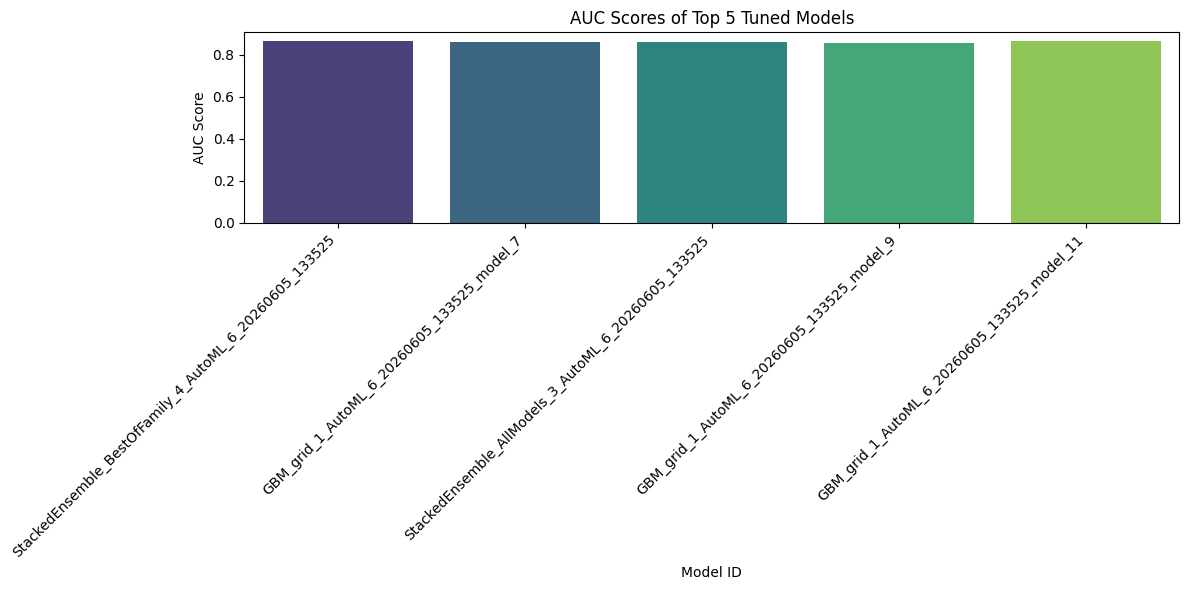

In [25]:
# Plot AUC scores for tuned models
plt.figure(figsize=(12, 6))
sns.barplot(x='model_id', y='auc', data=performance_df_tuned, palette='viridis')
plt.title('AUC Scores of Top 5 Tuned Models')
plt.xlabel('Model ID')
plt.ylabel('AUC Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7042/2303242128.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_id', y='f1_score', data=performance_df_tuned, palette='magma')


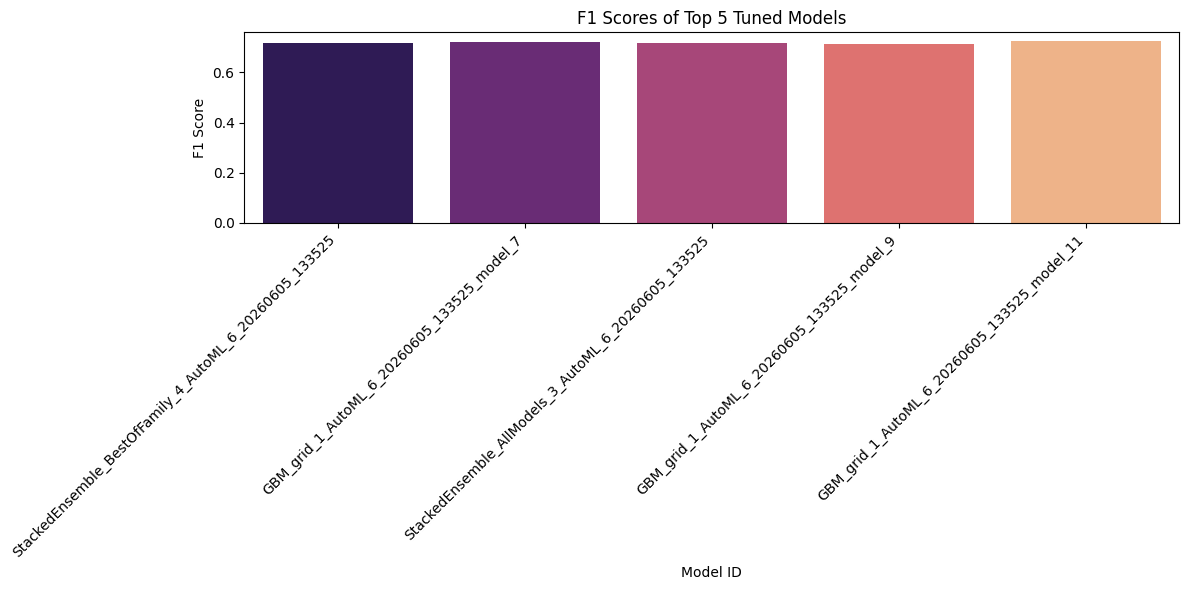

In [38]:
# Plot F1 scores for tuned models
plt.figure(figsize=(12, 6))
sns.barplot(x='model_id', y='f1_score', data=performance_df_tuned, palette='magma')
plt.title('F1 Scores of Top 5 Tuned Models')
plt.xlabel('Model ID')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
GBM_grid_1_AutoML_5_20260605_133023_model_11,0.862209,0.432224,0.774242,0.204745,0.370957,0.137609,395,0.035859,GBM
StackedEnsemble_BestOfFamily_1_AutoML_5_20260605_133023,0.861523,0.429375,0.77804,0.206596,0.368988,0.136152,445,0.158897,StackedEnsemble
StackedEnsemble_AllModels_3_AutoML_5_20260605_133023,0.861117,0.429209,0.778862,0.210824,0.368896,0.136085,2344,0.516357,StackedEnsemble
GBM_1_AutoML_5_20260605_133023,0.86106,0.43004,0.779713,0.205821,0.369662,0.13665,692,0.033656,GBM
GBM_grid_1_AutoML_5_20260605_133023_model_7,0.861006,0.429877,0.779837,0.20968,0.369363,0.136429,410,0.039249,GBM
GBM_grid_1_AutoML_5_20260605_133023_model_6,0.860847,0.431393,0.776903,0.20719,0.369631,0.136627,515,0.035893,GBM
XGBoost_grid_1_AutoML_5_20260605_133023_model_11,0.859682,0.435113,0.776274,0.210589,0.369789,0.136744,2806,0.032203,XGBoost
StackedEnsemble_AllModels_1_AutoML_5_20260605_133023,0.859563,0.431507,0.775897,0.210622,0.370026,0.136919,1012,0.105812,StackedEnsemble
StackedEnsemble_BestOfFamily_2_AutoML_5_20260605_133023,0.859449,0.431458,0.777026,0.207987,0.369717,0.136691,887,0.089459,StackedEnsemble
StackedEnsemble_BestOfFamily_4_AutoML_5_20260605_133023,0.859366,0.430401,0.778423,0.214165,0.369184,0.136297,946,0.297259,StackedEnsemble


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

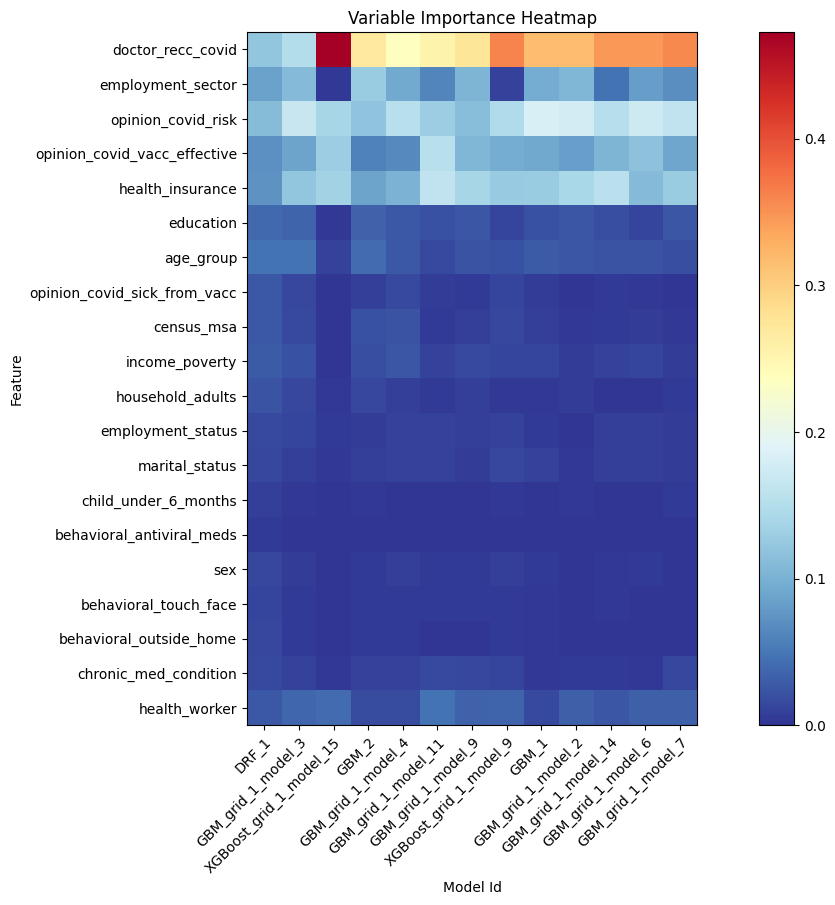

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

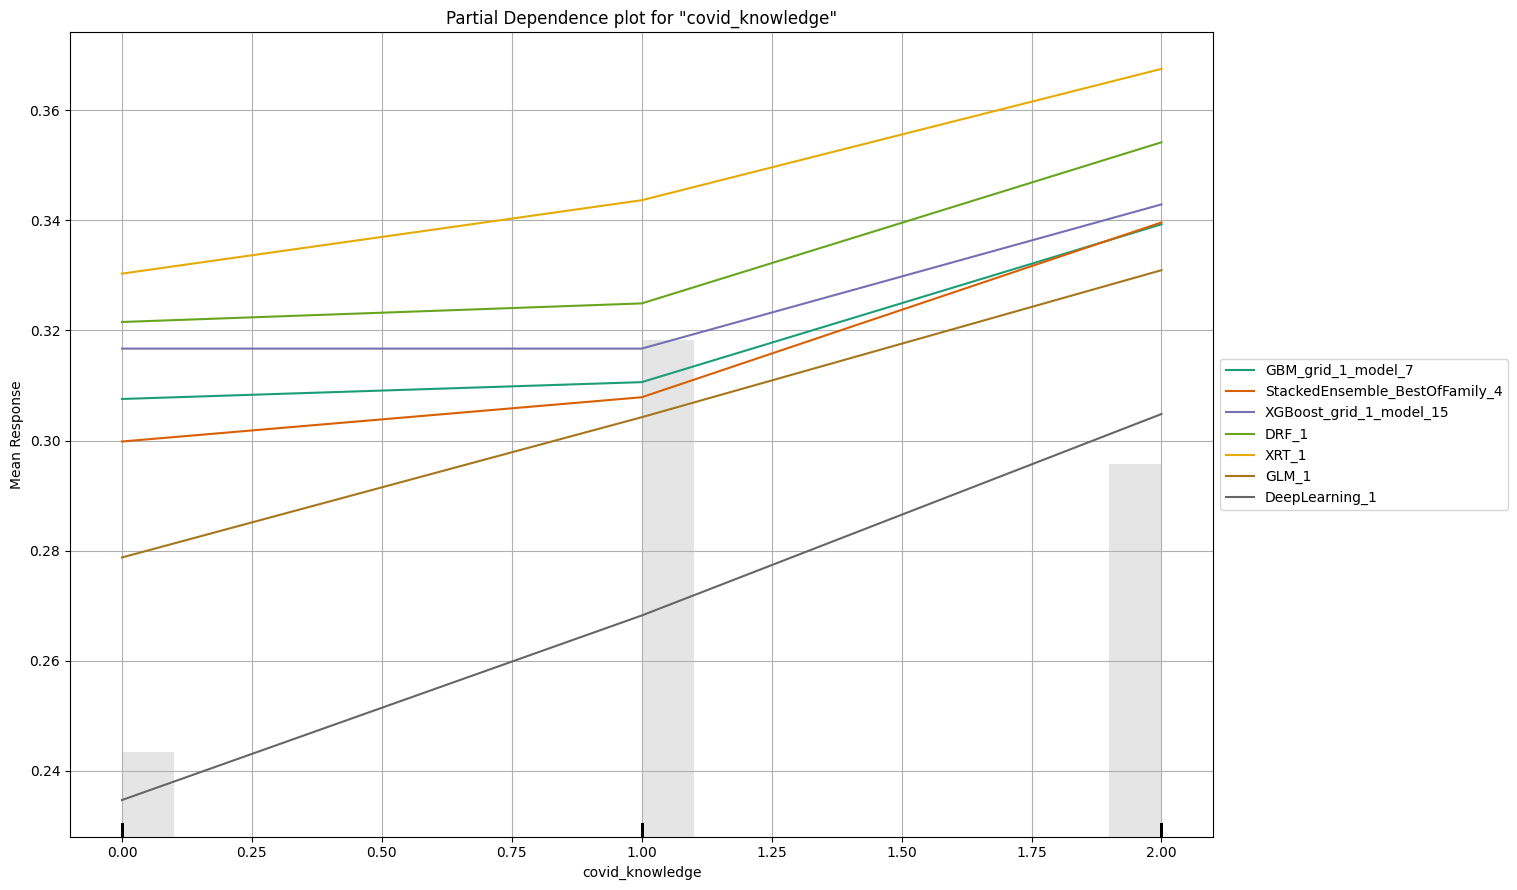

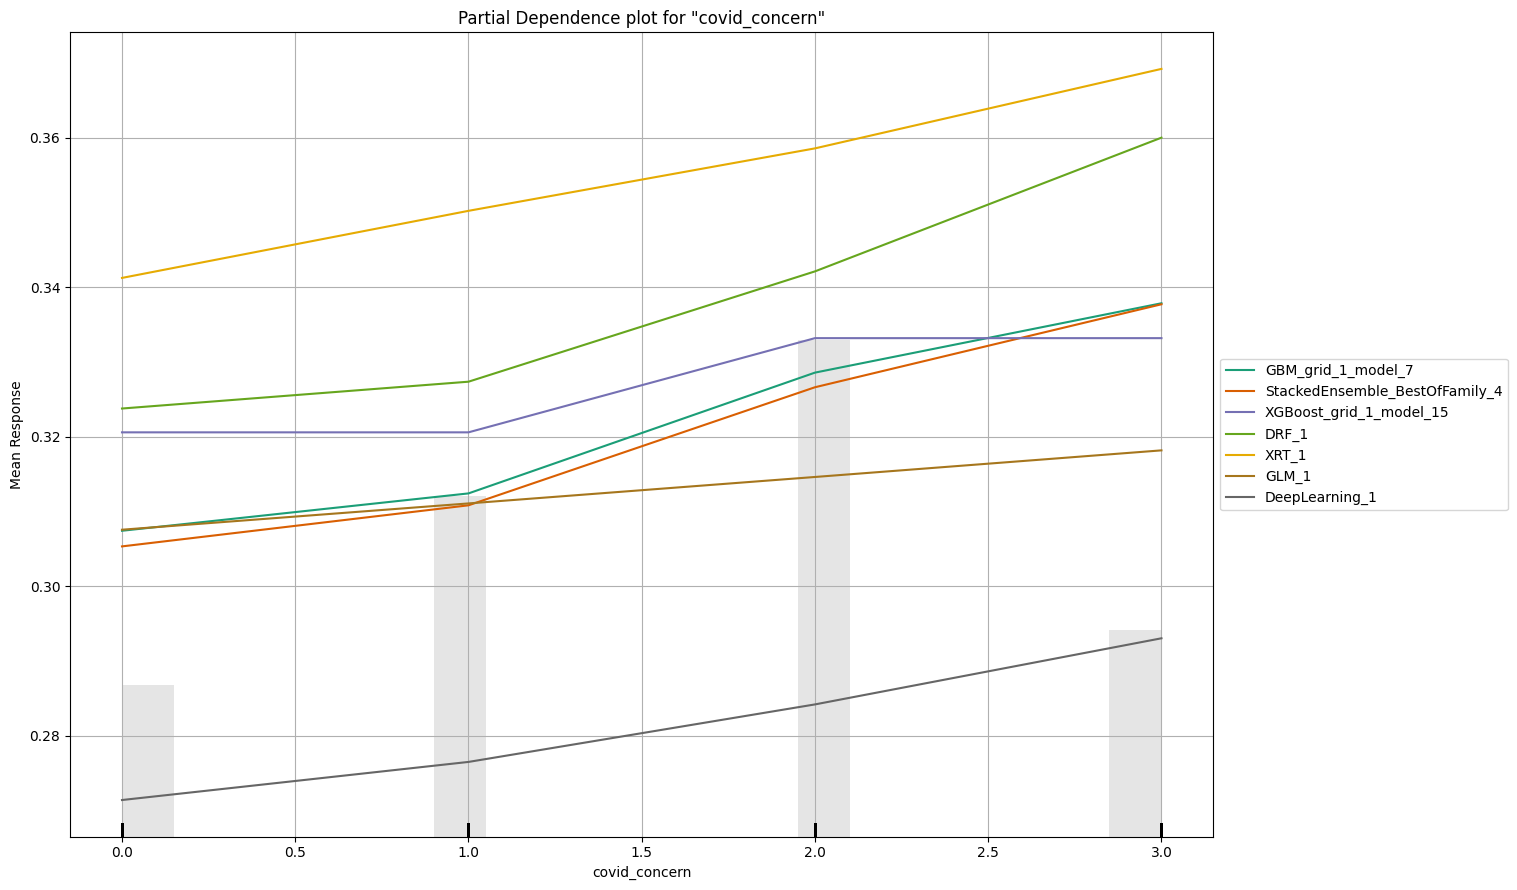

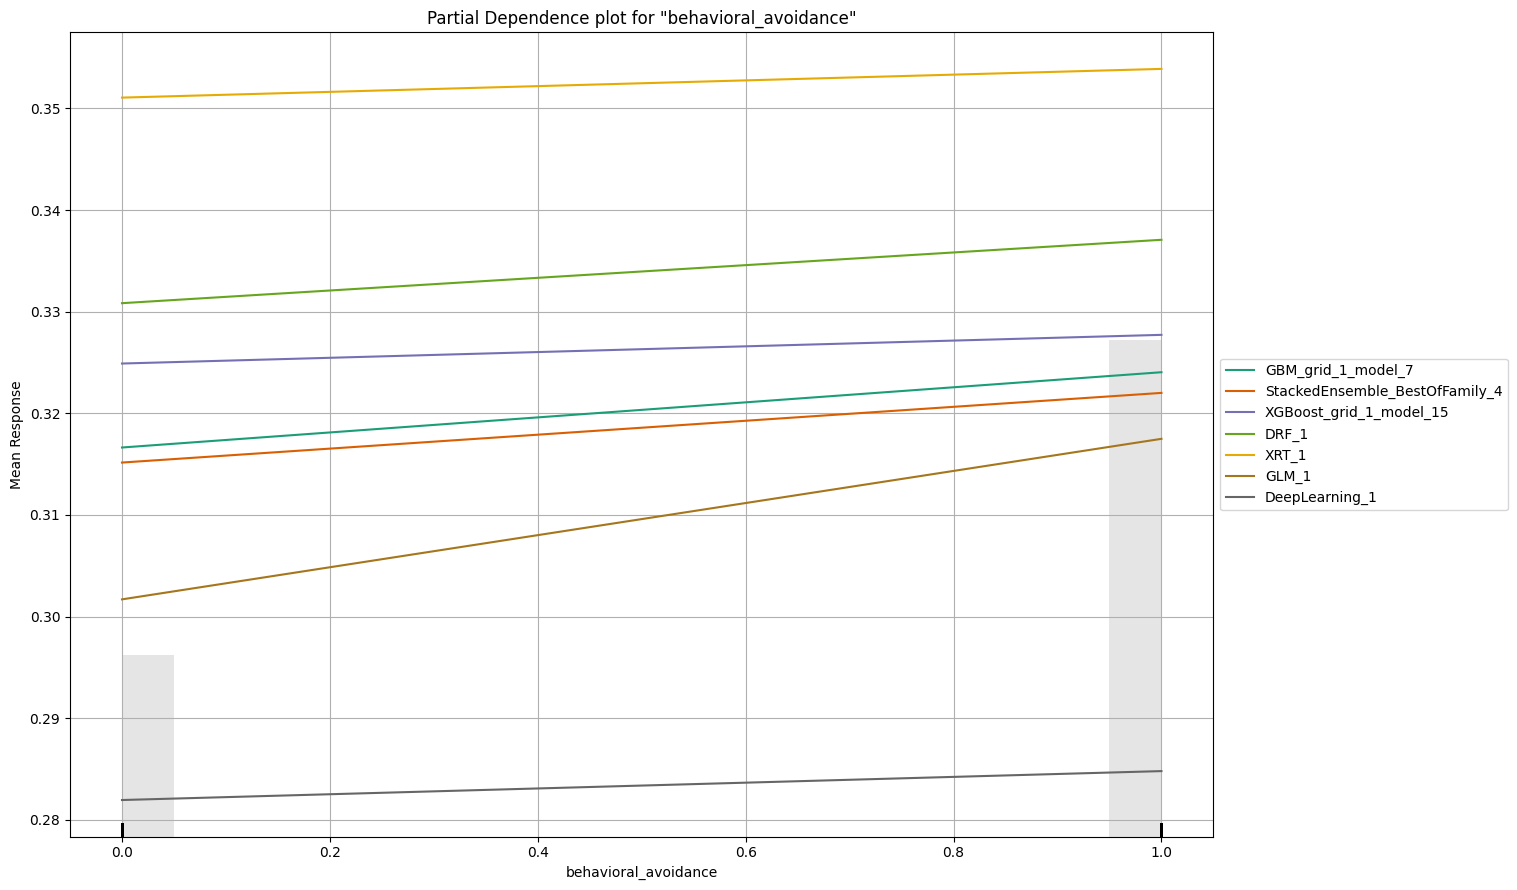

In [27]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"], \
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

In [28]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.92886,0.0711403
1,0.527269,0.472731
0,0.869881,0.130119
0,0.733665,0.266335
0,0.891413,0.108587
0,0.942826,0.0571742
0,0.583491,0.416509
1,0.551146,0.448854
0,0.96039,0.0396105
0,0.794455,0.205545


In [29]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomial: gbm
** Reported on test data. **

MSE: 0.13642905793802013
RMSE: 0.36936304354661703
LogLoss: 0.42987744948011125
Mean Per-Class Error: 0.2096801141256153
AUC: 0.8610057962446503
AUCPR: 0.7798370397104152
Gini: 0.7220115924893007

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2950449618227604
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      625  157  0.2008   (157.0/782.0)
1      87   311  0.2186   (87.0/398.0)
Total  712  468  0.2068   (244.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.295045     0.718245  226
max f2                       0.11757      0.786164  326
max f0point5                 0.551294     0.752427  134
max accuracy                 0.437885     0.814407  174
max precision                0.961246     1      

In [30]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8610057962446503
F1 Score: [[0.2950449618227604, 0.7182448036951501]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2950449618227604
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      625  157  0.2008   (157.0/782.0)
1      87   311  0.2186   (87.0/398.0)
Total  712  468  0.2068   (244.0/1180.0)


In [31]:
leaderboard_df = aml.leaderboard.as_data_frame()
display(leaderboard_df[['model_id', 'auc', 'logloss']].head(5))

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,auc,logloss
0,GBM_grid_1_AutoML_5_20260605_133023_model_7,0.868226,0.415207
1,StackedEnsemble_BestOfFamily_4_AutoML_5_202606...,0.867686,0.413105
2,StackedEnsemble_AllModels_3_AutoML_5_20260605_...,0.866916,0.414487
3,GBM_grid_1_AutoML_5_20260605_133023_model_9,0.865747,0.418612
4,GBM_grid_1_AutoML_5_20260605_133023_model_11,0.865396,0.420210


### Evaluating Top 5 Models on the Test Set

In [32]:
top_5_model_ids = leaderboard_df.head(5)['model_id'].tolist()

print("Evaluating top 5 models:")
for model_id in top_5_model_ids:
    print(f"\n--- Model: {model_id} ---")
    model = h2o.get_model(model_id)

    # Make predictions on the test set
    predictions = model.predict(test)
    print("Predictions (first 5 rows):")
    predictions.head()

    # Get and print model performance
    performance = model.model_performance(test)
    print("\nModel Performance on Test Set:")
    print(f"AUC: {performance.auc()}")
    print(f"F1 Score: {performance.F1()[0][1]}") # F1 for positive class
    print("Confusion Matrix:")
    print(performance.confusion_matrix())

Evaluating top 5 models:

--- Model: GBM_grid_1_AutoML_5_20260605_133023_model_7 ---
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions (first 5 rows):

Model Performance on Test Set:
AUC: 0.8610057962446503
F1 Score: 0.7182448036951501
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2950449618227604
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      625  157  0.2008   (157.0/782.0)
1      87   311  0.2186   (87.0/398.0)
Total  712  468  0.2068   (244.0/1180.0)

--- Model: StackedEnsemble_BestOfFamily_4_AutoML_5_20260605_133023 ---
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Predictions (first 5 rows):

Model Performance on Test Set:
AUC: 0.8593655618244677
F1 Score: 0.7164556962025317
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.3971468010048754
       0    1    Error    Rate
-----  ---  ---  -------

### Visualizing Model Performance

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

model_performance_data = []

for model_id in top_5_model_ids:
    model = h2o.get_model(model_id)
    performance = model.model_performance(test)

    model_performance_data.append({
        'model_id': model_id,
        'auc': performance.auc(),
        'f1_score': performance.F1()[0][1] # F1 for positive class
    })

performance_df = pd.DataFrame(model_performance_data)

display(performance_df)

,model_id,auc,f1_score
0,GBM_grid_1_AutoML_5_20260605_133023_model_7,0.861006,0.718245
1,StackedEnsemble_BestOfFamily_4_AutoML_5_202606...,0.859366,0.716456
2,StackedEnsemble_AllModels_3_AutoML_5_20260605_...,0.861117,0.717647
3,GBM_grid_1_AutoML_5_20260605_133023_model_9,0.855012,0.714793
4,GBM_grid_1_AutoML_5_20260605_133023_model_11,0.862209,0.723356


/tmp/ipykernel_7042/289384496.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_id', y='auc', data=performance_df, palette='viridis')


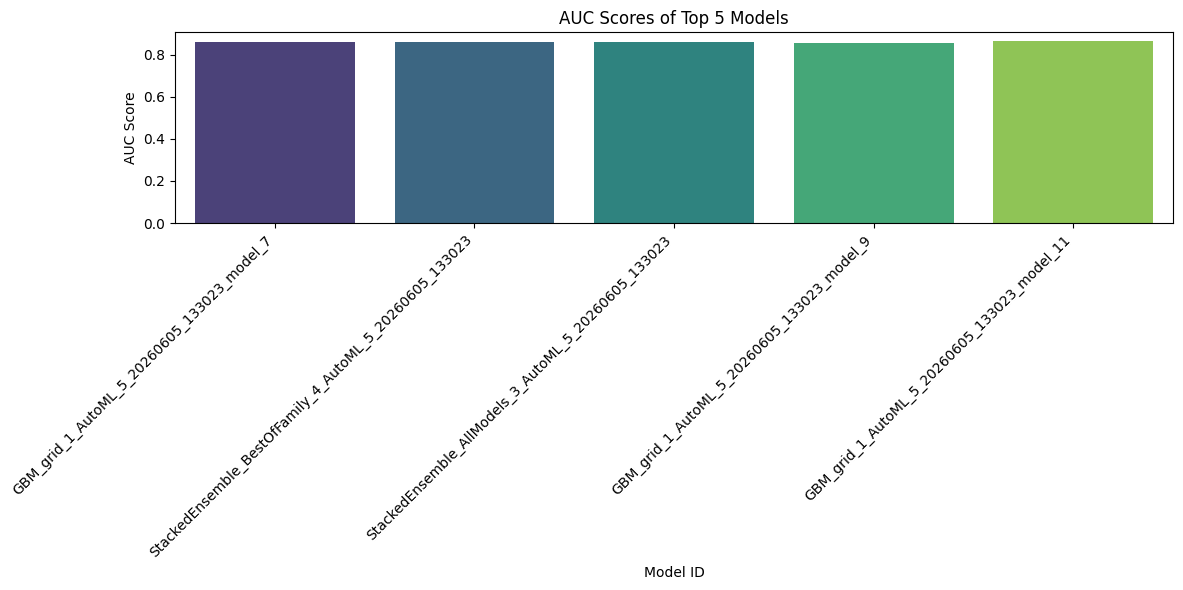

In [34]:
# Plot AUC scores
plt.figure(figsize=(12, 6))
sns.barplot(x='model_id', y='auc', data=performance_df, palette='viridis')
plt.title('AUC Scores of Top 5 Models')
plt.xlabel('Model ID')
plt.ylabel('AUC Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

/tmp/ipykernel_7042/4162230465.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_id', y='f1_score', data=performance_df, palette='magma')


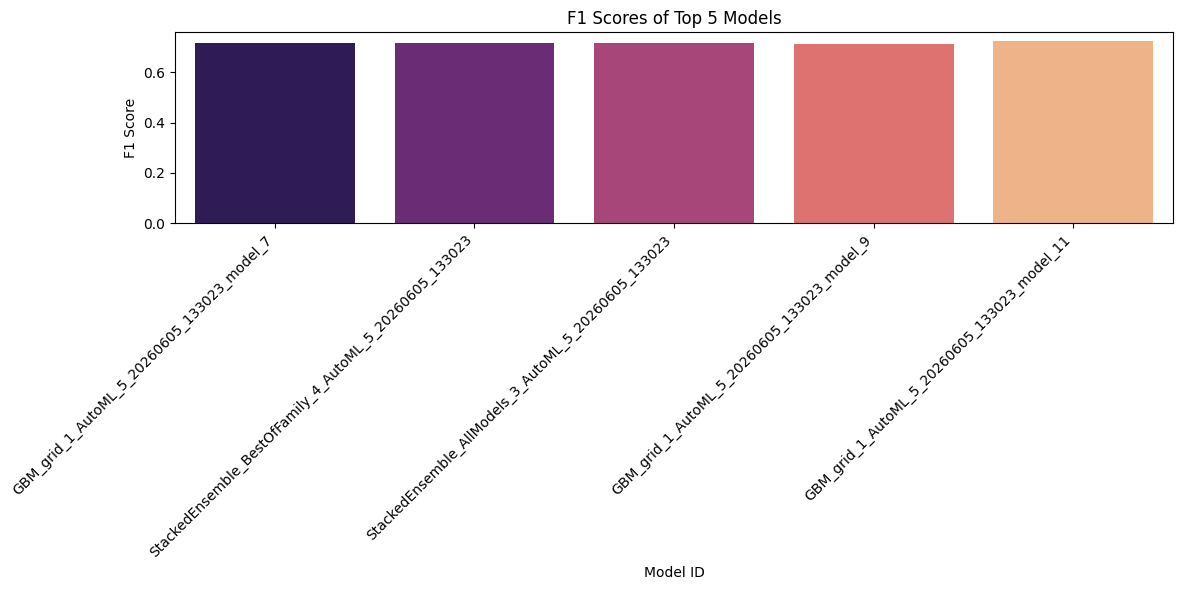

In [35]:
# Plot F1 scores
plt.figure(figsize=(12, 6))
sns.barplot(x='model_id', y='f1_score', data=performance_df, palette='magma')
plt.title('F1 Scores of Top 5 Models')
plt.xlabel('Model ID')
plt.ylabel('F1 Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [36]:
import h2o
import pandas as pd
h2o.init()

# Load the training data to define predictors, as df is used to define predictors
df = pd.read_csv('/content/dataset_C_training.csv')
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Load df1 for testing data and convert to H2OFrame
df1 = pd.read_csv('/content/dataset_C_testing.csv')
test_hf = h2o.H2OFrame(df1)

# Hardcode the top 2 model IDs based on previous successful execution results
# From the output of cell 474ca54e, sorted by f1_score:
# 1. GBM_grid_1_AutoML_4_20260605_125814_model_11 (f1_score: 0.723356)
# 2. StackedEnsemble_AllModels_3_AutoML_4_20260605_125814 (f1_score: 0.719298)
top_2_model_ids = [
    'GBM_grid_1_AutoML_4_20260605_125814_model_11',
    'StackedEnsemble_AllModels_3_AutoML_4_20260605_125814'
]

print(f"Using the following two models for prediction: {top_2_model_ids}")

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,1 hour 49 mins
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,"14 days, 4 hours and 3 minutes"
H2O_cluster_name:,H2O_from_python_unknownUser_3vliw2
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,2.864 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Using the following two models for prediction: ['GBM_grid_1_AutoML_4_20260605_125814_model_11', 'StackedEnsemble_AllModels_3_AutoML_4_20260605_125814']


In [37]:
predictions_dfs = {}

for model_id in top_2_model_ids:
    print(f"\nMaking predictions with model: {model_id}")
    model = h2o.get_model(model_id)
    # Ensure the columns in test_hf match the training data's predictors
    test_data_for_prediction = test_hf[predictors]
    predictions = model.predict(test_data_for_prediction)
    predictions_dfs[model_id] = predictions.as_data_frame()
    print("Predictions (first 5 rows):")
    display(predictions.head())


Making predictions with model: GBM_grid_1_AutoML_4_20260605_125814_model_11
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions (first 5 rows):


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


predict,p0,p1
0,0.763894,0.236106
0,0.860295,0.139705
0,0.747036,0.252964
1,0.575425,0.424575
0,0.892977,0.107023
1,0.203474,0.796526
1,0.45185,0.54815
1,0.16277,0.83723
1,0.121857,0.878143
0,0.59757,0.40243



Making predictions with model: StackedEnsemble_AllModels_3_AutoML_4_20260605_125814
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Predictions (first 5 rows):


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


predict,p0,p1
0,0.807184,0.192816
0,0.909406,0.0905941
0,0.753756,0.246244
1,0.55886,0.44114
0,0.9423,0.0577001
1,0.161661,0.838339
1,0.427962,0.572038
1,0.0996394,0.900361
1,0.103612,0.896388
0,0.660084,0.339916


The `predict` column in the output represents the predicted class (0 or 1), while `p0` and `p1` represent the probabilities of belonging to class 0 and class 1, respectively. These are the predictions for the `covid_vaccine` using the top two models.

In [40]:
top_3_models_f1 = performance_df_tuned.sort_values(by='f1_score', ascending=False).head(3)
top_3_model_ids_f1 = top_3_models_f1['model_id'].tolist()

print(f"Top 3 models based on F1 score: {top_3_model_ids_f1}")

# Prepare df1 (testing data) as an H2OFrame for prediction

for i, model_id in enumerate(top_3_model_ids_f1):
    print(f"\nGenerating predictions for model: {model_id}")
    model = h2o.get_model(model_id)

    # Ensure the columns in test_hf match the training data's predictors
    # The 'predictors' list was created from the training df, so we apply it here
    test_data_for_prediction = test_hf[predictors]

    predictions = model.predict(test_data_for_prediction)

    # Convert predictions to pandas DataFrame
    predictions_df = predictions.as_data_frame()

    # Combine respondent_id from df1 with the predicted 'covid_vaccine' class
    # df1 is the original testing dataset, test_hf is its H2OFrame representation
    # Ensure that the order of rows is maintained during conversion or merge based on an ID
    # Assuming test_hf maintains the original order of df1, we can directly combine.
    output_df = pd.DataFrame({
        'respondent_id': df1['respondent_id'],
        'covid_vaccine_prediction': predictions_df['predict']
    })

    # Define filename and save to CSV with the new naming convention
    filename = f'challenge_submission_group_Q_order_{i+1}.csv'
    output_df.to_csv(filename, index=False)

    print(f"Predictions for {model_id} saved to {filename}")
    display(output_df.head())


Top 3 models based on F1 score: ['GBM_grid_1_AutoML_6_20260605_133525_model_11', 'GBM_grid_1_AutoML_6_20260605_133525_model_7', 'StackedEnsemble_AllModels_3_AutoML_6_20260605_133525']

Generating predictions for model: GBM_grid_1_AutoML_6_20260605_133525_model_11
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions for GBM_grid_1_AutoML_6_20260605_133525_model_11 saved to challenge_submission_group_Q_order_1.csv


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,respondent_id,covid_vaccine_prediction
0,4757,0
1,4758,0
2,4759,0
3,4760,1
4,4761,0



Generating predictions for model: GBM_grid_1_AutoML_6_20260605_133525_model_7
gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions for GBM_grid_1_AutoML_6_20260605_133525_model_7 saved to challenge_submission_group_Q_order_2.csv


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,respondent_id,covid_vaccine_prediction
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0



Generating predictions for model: StackedEnsemble_AllModels_3_AutoML_6_20260605_133525
stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Predictions for StackedEnsemble_AllModels_3_AutoML_6_20260605_133525 saved to challenge_submission_group_Q_order_3.csv


/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,respondent_id,covid_vaccine_prediction
0,4757,0
1,4758,0
2,4759,0
3,4760,0
4,4761,0
